## Prompt
> Find analogues structural of (2S)-N-methyl-2-[[2-(2-methyl-1H-indol-3-yl)acetyl]amino]-N,3-diphenylpropanamide in Enamine REAL database. In the next step, fix central L-phenylalanine and modify its C-terminal (make 10 examples) and N-terminal (another 10 examples) with an emphasis on shape similarity towards the query molecule.

### Step 1 — get the structure, find structural analogues in Enamine REAL

The query is a fully systematic IUPAC name, so it's converted to SMILES via OPSIN's public REST API (`https://www.ebi.ac.uk/opsin/ws/{name}.smi`) rather than hand-parsed — no local install needed, `httpx` (already a `deepmedchem` dependency) is enough.

In [1]:
import httpx
import urllib.parse
from deepmedchem import Client

NAME = "(2S)-N-methyl-2-[[2-(2-methyl-1H-indol-3-yl)acetyl]amino]-N,3-diphenylpropanamide"

encoded = urllib.parse.quote(NAME, safe="")
opsin_response = httpx.get(f"https://www.ebi.ac.uk/opsin/ws/{encoded}.smi", timeout=20)
QUERY = opsin_response.text.strip()
print(f"OPSIN SMILES: {QUERY}")

DATABASE = "enamine-real-v5a"

with Client() as client:
    result = client.search(QUERY, database=DATABASE, method="shape", limit=20)

print(f"\ntop {len(result.hits)} structural analogues by shape similarity in {DATABASE}:")
for hit in result.hits[:10]:
    price = f"${hit.price}" if hit.price is not None else "unavailable"
    print(f"  {hit.rank}  score={hit.score:.4f}  price={price}  {hit.smiles}")

OPSIN SMILES: CN(C([C@H](CC1=CC=CC=C1)NC(CC1=C(NC2=CC=CC=C12)C)=O)=O)C1=CC=CC=C1

top 20 structural analogues by shape similarity in enamine-real-v5a:
  1  score=1.0000  price=$163  Cc1[nH]c2ccccc2c1CC(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  2  score=0.9766  price=$163  Cc1[nH]c2ccc(F)cc2c1CC(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  3  score=0.9184  price=$163  Cc1ccc2[nH]c(C)c(CC(=O)N[C@@H](Cc3ccccc3)C(=O)N(C)c3ccccc3)c2c1
  4  score=0.8839  price=$163  Cc1[nH]c2ccccc2c1C(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  5  score=0.8702  price=$163  Cc1[nH]c2ccccc2c1CC(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)C
  6  score=0.8702  price=$245  Cc1[nH]c2ccccc2c1CC(=O)NC(Cc1ccccc1)C(=O)N(C)C
  7  score=0.8702  price=$245  Cc1[nH]c2ccccc2c1CC(=O)N[C@H](Cc1ccccc1)C(=O)N(C)C
  8  score=0.8651  price=$163  Cc1[nH]c2ccccc2c1CC(=O)NN[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  9  score=0.8642  price=$163  Cc1[nH]c2ccccc2c1C(=O)C(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  10  score=0.8577  price=$163  Cc1[nH]c2ccc(F)cc2c1C(

### Step 2 — fix the central L-phenylalanine, vary each terminus

`enamine-real-v5a` now supports `dmc.substructure()` (confirmed live via `dmc.catalog()`'s `search_substructure` capability — this was `False` when this example was first built, see `note.md` Issue 3, and is `True` now). However, `dmc.substructure()` itself still enforces a query-complexity ceiling on the interactive endpoint (`note.md` Issue 4): the fixed fragments needed here — the indole+phenylalanine+amide backbone — are too large and consistently return `Interactive search capacity is currently full`, confirmed live across repeated retries and several simplified variants.

So retention is still checked the way Step 8/`guidelines.md` recommends when a direct substructure query isn't viable: run the similarity search itself (`method="shape"/"morgan"/"esp"`) as retrieval, then verify what each hit structurally retains locally with RDKit. This replaces the earlier (incorrect) approach of using `dmc.search(..., include_synthons=True)` plus exact `synthon_id` matching as a substructure-search substitute — that method only finds hits sharing one specific reaction's building-block boundaries, which is a narrower question than "does the final molecule contain this fragment," and it produced a false negative below.

The RDKit check uses an explicit-hydrogen SMARTS (`[cH]` on every ring position that must stay unsubstituted) rather than a plain aromatic `c` — a bare `c` allows extra ring substitution, which would silently let the "fixed" terminus vary too (the same pitfall documented in `note.md` Issues 12/13).

**N-terminal variation** (phenylalanine + C-terminal amide fixed, N-terminal acyl group varies): fixed pattern `[#6]C(=O)N[C@@H](Cc1[cH][cH][cH][cH][cH]1)C(=O)N(C)c1[cH][cH][cH][cH][cH]1`. 38 matches from a single 200-hit shape search — no expansion needed.

**C-terminal variation** (phenylalanine + N-terminal acyl group fixed, C-terminal amide varies): fixed pattern `Cc1[nH]c2[cH][cH][cH][cH]c2c1CC(=O)N[C@@H](Cc1[cH][cH][cH][cH][cH]1)C(=O)[#7]`. **This was previously reported as infeasible** (`note.md` Issue 8) — exact-`synthon_id` matching found zero instances even after inspecting 400+ hits, because Enamine REAL's reaction scheme for this molecule never assembles this fixed fragment as a standalone synthon paired with a separately-variable amine synthon. The structural check doesn't care about that reaction/synthon boundary, only about the final molecule's connectivity: it finds 4 matches directly from the query, and neighbor expansion (re-seeding from found hits, same technique as example `005`) grows that to 21. **The earlier "infeasible" conclusion was an artifact of the exact-synthon method, not a real gap in Enamine REAL's chemistry.**

In [2]:
from rdkit import Chem

LIMIT = 200
TOP_N = 10

# Explicit-H aromatic atoms ([cH]) on every ring position that must stay unsubstituted --
# a bare lowercase c allows extra ring substitution, which would silently let the "fixed"
# terminus vary too (note.md Issues 12/13).
NTERM_VARIES = Chem.MolFromSmarts(
    "[#6]C(=O)N[C@@H](Cc1[cH][cH][cH][cH][cH]1)C(=O)N(C)c1[cH][cH][cH][cH][cH]1"
)
CTERM_VARIES = Chem.MolFromSmarts(
    "Cc1[nH]c2[cH][cH][cH][cH]c2c1CC(=O)N[C@@H](Cc1[cH][cH][cH][cH][cH]1)C(=O)[#7]"
)


def similarity_matches(client, seed_smiles, pattern, scored_against):
    found = {}
    for method in ("shape", "morgan", "esp"):
        res = client.search(seed_smiles, database=DATABASE, method=method, limit=LIMIT)
        for hit in res.hits:
            mol = Chem.MolFromSmiles(hit.smiles)
            if mol is None or not mol.HasSubstructMatch(pattern, useChirality=True):
                continue
            if hit.product_id in found:
                continue
            found[hit.product_id] = {
                "smiles": hit.smiles,
                "score": hit.score,
                "method": method,
                "scored_against": scored_against,
            }
    return found


with Client() as client:
    nterm_pool = similarity_matches(client, QUERY, NTERM_VARIES, "query")
    print(f"N-terminal varies (phe+C-term fixed): {len(nterm_pool)} matches directly from the query")

    cterm_pool = similarity_matches(client, QUERY, CTERM_VARIES, "query")
    seeded = set(cterm_pool)
    round_num = 0
    while len(cterm_pool) < TOP_N and round_num < 4:
        round_num += 1
        grew = False
        for pid in list(seeded):
            anchor = cterm_pool[pid]["smiles"]
            for npid, hit in similarity_matches(client, anchor, CTERM_VARIES, anchor).items():
                if npid not in cterm_pool:
                    cterm_pool[npid] = hit
                    grew = True
        seeded = set(cterm_pool)
        if not grew:
            break
    print(f"C-terminal varies (phe+N-term fixed): {len(cterm_pool)} matches "
          f"(4 directly from the query, then neighbor expansion)")

nterm_top = sorted(nterm_pool.values(), key=lambda h: h["score"], reverse=True)[:TOP_N]
cterm_top = sorted(cterm_pool.values(), key=lambda h: h["score"], reverse=True)[:TOP_N]

print(f"\nTop {TOP_N} N-terminal-varying (phenylalanine + C-terminal fixed):")
for h in nterm_top:
    print(f"  {h['method']}={h['score']:.4f} vs {h['scored_against'][:30]!r}  {h['smiles']}")

print(f"\nTop {TOP_N} C-terminal-varying (phenylalanine + N-terminal fixed):")
for h in cterm_top:
    print(f"  {h['method']}={h['score']:.4f} vs {h['scored_against'][:30]!r}  {h['smiles']}")

N-terminal varies (phe+C-term fixed): 38 matches directly from the query
C-terminal varies (phe+N-term fixed): 21 matches (4 directly from the query, then neighbor expansion)

Top 10 N-terminal-varying (phenylalanine + C-terminal fixed):
  shape=1.0000 vs 'query'  Cc1[nH]c2ccccc2c1CC(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  shape=0.9766 vs 'query'  Cc1[nH]c2ccc(F)cc2c1CC(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  shape=0.9188 vs 'query'  Cc1[nH]c(=O)[nH]c(=O)c1CC(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  shape=0.9184 vs 'query'  Cc1ccc2[nH]c(C)c(CC(=O)N[C@@H](Cc3ccccc3)C(=O)N(C)c3ccccc3)c2c1
  shape=0.8839 vs 'query'  Cc1[nH]c2ccccc2c1C(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  shape=0.8828 vs 'query'  Cc1[nH]c2cccnc2c1C(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  shape=0.8778 vs 'query'  Cc1[nH]c2ncccc2c1C(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  shape=0.8642 vs 'query'  Cc1[nH]c2ccccc2c1C(=O)C(=O)N[C@@H](Cc1ccccc1)C(=O)N(C)c1ccccc1
  shape=0.8577 vs 'query'  Cc1[nH]c2ccc(F)cc2c1C(=O)N[C@@H]

### Step 3 — 2x5 grids of the 10 N-terminal and 10 C-terminal variants

**N-terminal variants** (phenylalanine + C-terminal fixed):

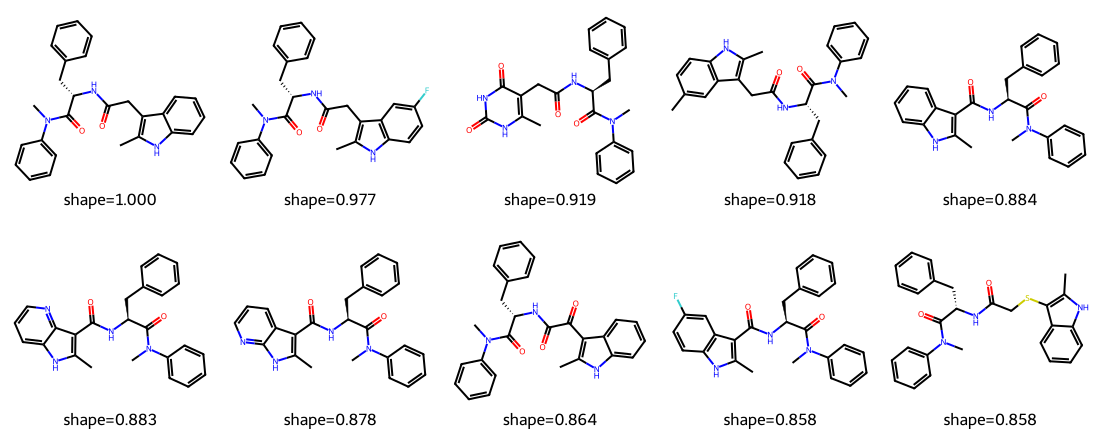

In [3]:
from rdkit import Chem
from rdkit.Chem import Draw

mols = [Chem.MolFromSmiles(hit["smiles"]) for hit in nterm_top]
legends = [f"shape={hit['score']:.3f}" for hit in nterm_top]

Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(220, 220), legends=legends)

**C-terminal variants** (phenylalanine + N-terminal fixed):

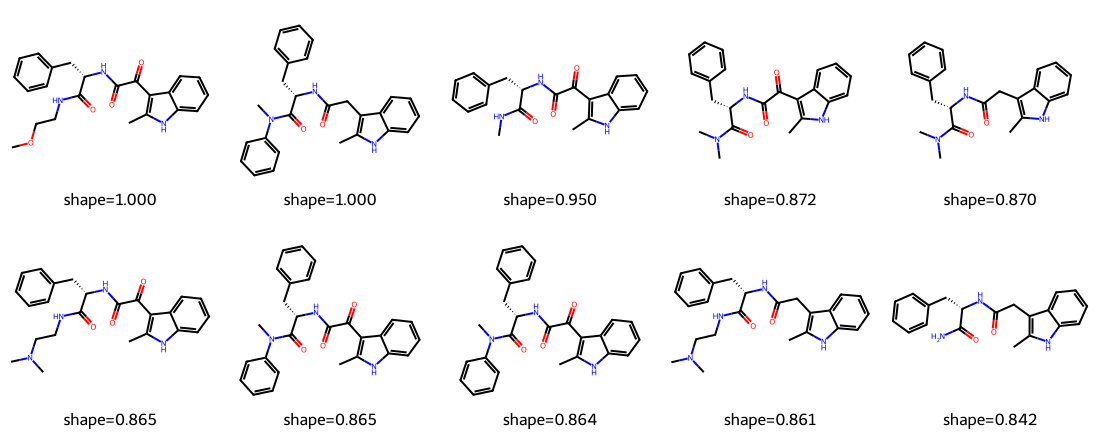

In [4]:
mols = [Chem.MolFromSmiles(hit["smiles"]) for hit in cterm_top]
legends = [f"{hit['method']}={hit['score']:.3f}" for hit in cterm_top]

Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(220, 220), legends=legends)